In [ ]:
import numpy as np
from pathlib import Path
import os, sys
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import warnings
import pandas as pd

repo_root = Path("/home/thardy/elefanto/ConsciousnessTeam_Data/SOUNDMODEL/Data_SoundGOOD/LEAD_ExperimentalFolder")
os.chdir(repo_root)

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
os.environ["PYTHONPATH"] = str(repo_root) + os.pathsep + os.environ.get("PYTHONPATH", "")

import LEAD as lead


# Important variables
cwd = Path.cwd()
SNRs = np.array([-np.inf,-13,-11,-9,-7,-5,-3])
SubIDs = ['01','02','03','05','06','07','08','09','11','12','13','14','15','17','19','20','22','23','24','25']
colormap = {0: (0, 0, 0), 1: (0, 0.25, 1), 2: (0, 0.9375, 1), 3: (0, 0.91, 0.1), 4: (1, 0.6, 0), 5: (1, 0, 0), 6: (0.8, 0, 0)}

# Publication-quality plotting defaults
plt.rcParams['figure.dpi'] = 200
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['savefig.pad_inches'] = 0.05

In [11]:
def count_sign_changes(delta_x):
    signs = np.sign(delta_x)
    sign_changes = np.sum(np.diff(signs) != 0)
    return sign_changes

def is_bifurcation(delta_x_list):
    counts = [count_sign_changes(delta_x) for delta_x in delta_x_list]
    unique_counts = set(counts)
    return len(unique_counts) > 1


In [ ]:
# Function to find the best (g, w) for displaying bifurcation
# states = np.linspace(-1, 3, 500)
# delta_x_list = []

# for cat in range(n_categories - 1):
#     # Initial state diff
#     delta_x_list.append(gainfixed.core(state=states, input_value=1, signal_category=cat) - states)
    
#     w1, w2 = getattr(gainfixed, f'w{cat}'), getattr(gainfixed, f'w{cat+1}')
    
#     # Travel on the w1 -> w2 segment
#     for t in np.linspace(0, 1, 100):
#         w = w1 + t*(w2-w1)
        
#         interp_model = lead.model.NonLinear1(
#             tau=gainfixed.tau, 
#             process_noise=gainfixed.process_noise, 
#             measure_noise=gainfixed.measure_noise, 
#             threshold=gainfixed.threshold, 
#             sharpness=gainfixed.sharpness, 
#             input_weight=w, 
#             gain=gainfixed.gain
#         )
#         # Note: signal_category=0 is used because NonLinear1 is non-stratified (single cat)
#         delta_x_list.append(interp_model.core(state=states, input_value=1, signal_category=0) - states)

# bifbool = is_bifurcation(delta_x_list) 

# Bifurcation Probability via Particle Density Estimation

{0: 0.948797914168062, 1: 7.229387461792482e-08, 2: 0.2619339387749689, 3: 0.0, 4: 0.5858826200787949, 5: 0.8816302243498213, 6: 0.9444490032311608, 7: 0.0, 8: 0.999996045032295, 9: 1.0, 10: 0.5288819736793646, 11: 0.2609157023306431, 12: 0.9900835145403318, 13: 1.0, 14: 0.99783284618011, 15: 0.0, 16: 0.9972614250499352, 17: 0.0, 18: 1.0, 19: 8.45194615159646e-91}
Plotting for Threshold: 0.7, Tau: 8.7


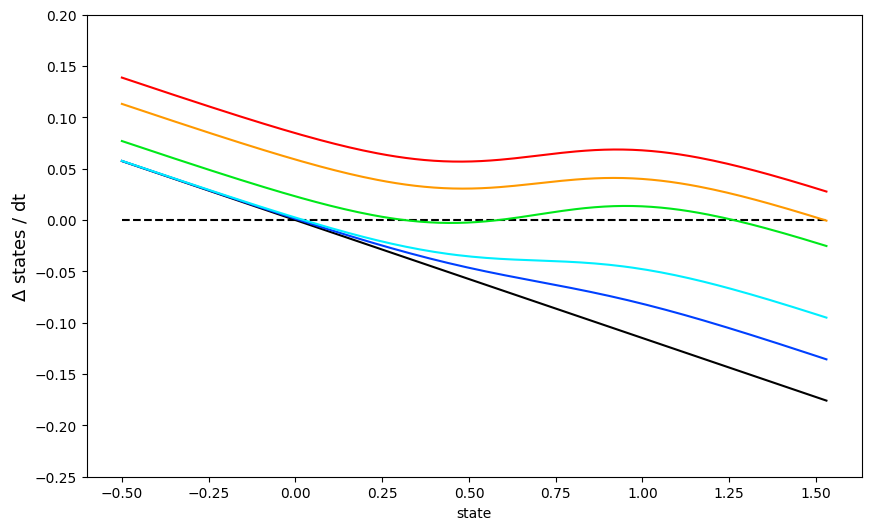

Plotting for Threshold: 0.2, Tau: 9


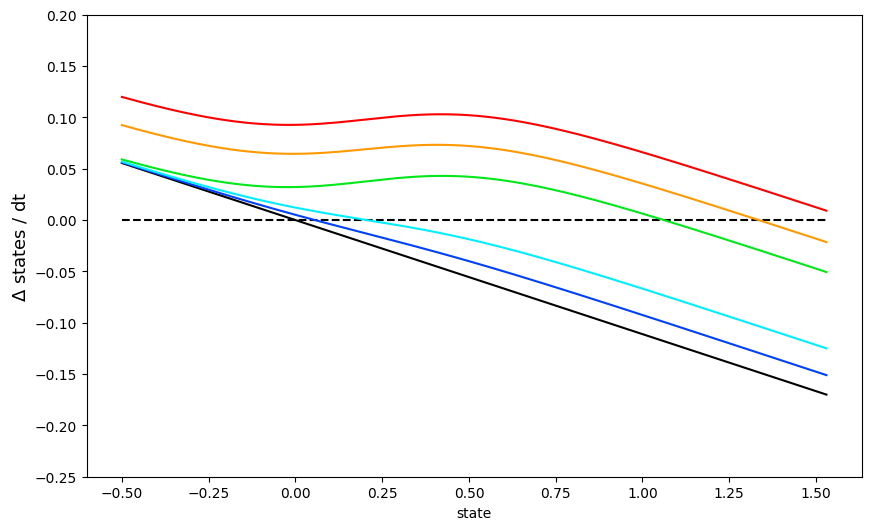

Plotting for Threshold: 0.8, Tau: 8.4


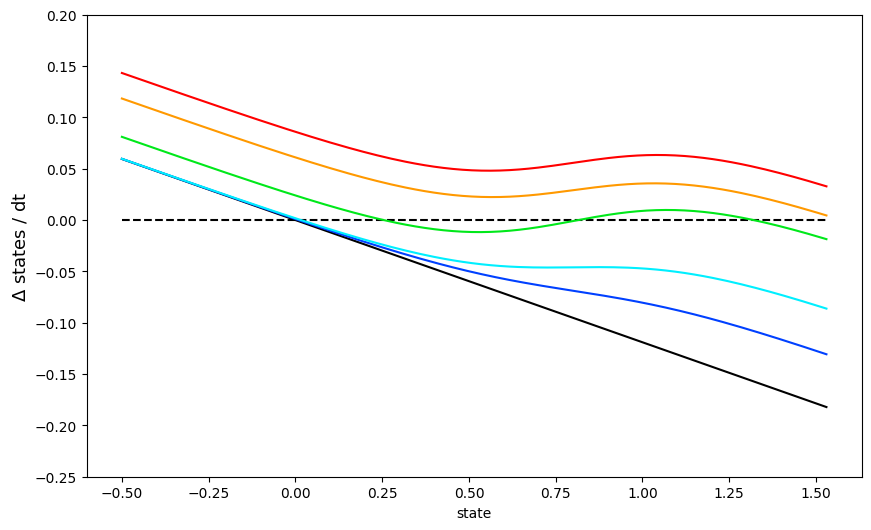

Plotting for Threshold: 1.1, Tau: 9.1


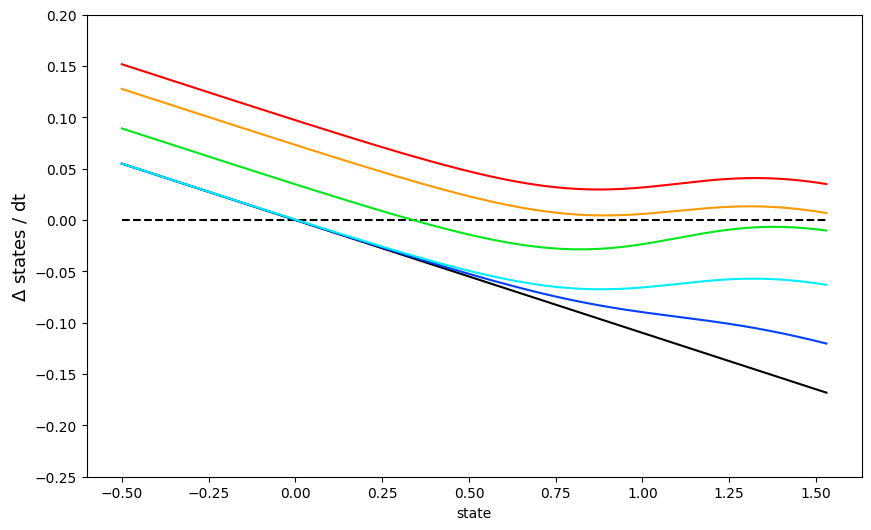

Plotting for Threshold: 1.75, Tau: 9.2


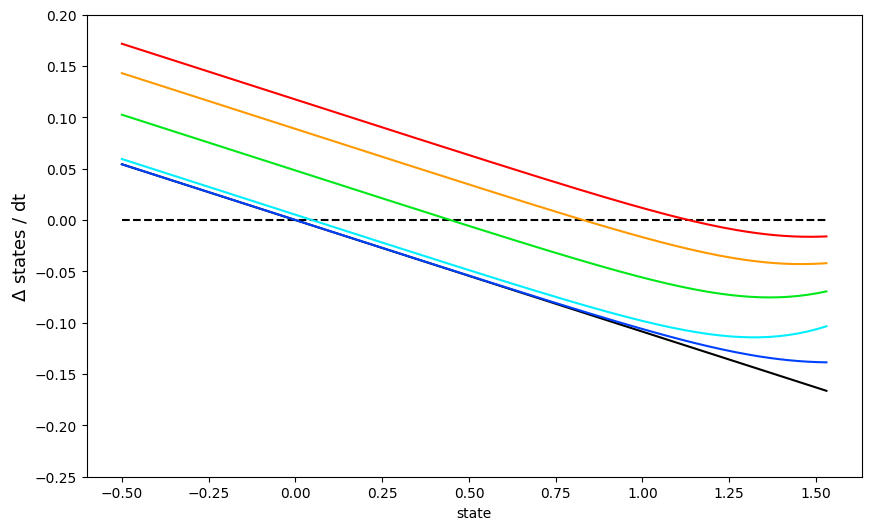

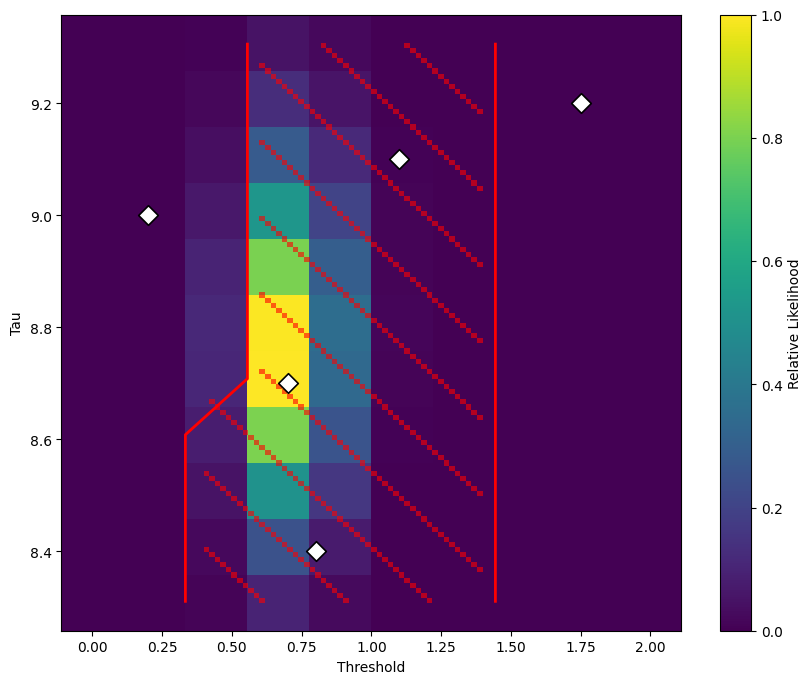

In [ ]:
part_figure = 6
task = "Active"
file_path = Path(f'Fit_{task}_late')
sub_file_path = "BifurcationProbability_Bounded"

# Define the summary path clearly and load existing progress 
summary_path = file_path / sub_file_path / "bifurcation_probabilities.csv"
existing_df = pd.read_csv(summary_path, index_col=0)
bifurcation_prob = existing_df["probability_of_bifurcation"].to_dict()
print(bifurcation_prob)

# Load data
data_ref = f'myEpochs_{task}/Epoch_{SubIDs[part_figure]}-epo.fif'
epochs_file = cwd.parents[0] / data_ref
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)
    state_train = lead.STG(epochs_file, tmin=300, tmax=500)
    n_categories = len(list(state_train.keys()))
    categories = list(range(n_categories))

# Input definition (same for all categories & trials)
one_input = np.concatenate((np.zeros(75), np.ones(25), np.zeros(150)))
input_train = {cat: np.stack([one_input for _ in range(state_train[cat].shape[0])]) for cat in categories}

# Isolate segments where stimulation is supposed constant
state_train_constant_stim = {cat: state_train[cat][:,75:100] for cat in range(1, n_categories)}
input_train_constant_stim = {cat: input_train[cat][:,75:100] for cat in range(1, n_categories)}

    
for part in [part_figure]: # range(20):

    # --- Load Parent Parameters ---
    gainmodul_parent = lead.model.StratifiedGainModulation(
        tau=10, process_noise=0.1, measure_noise=0.1, threshold=1, sharpness=5)
    param_path = file_path / f"GainModulatedModel_part{part}_params"
    gainmodul_parent.load_params(param_path)

    # Plot selected model samples 
    diamond_points = [(0.7, 8.7), 
                      (0.2, 9), 
                      (0.8, 8.4), 
                      (1.1, 9.1),
                      (1.75, 9.2)]  # (threshold, tau); edit these coordinates as needed
    states = np.linspace(-0.5, 1.53, 150)
    conditions = [(0, 0), (1, 1), (1,2), (1,3), (1,4), (1,5)]
    labels = {cat: str(cat) for cat in range(6)}
    for threshold, tau in diamond_points:
        print(f"Plotting for Threshold: {threshold}, Tau: {tau}")
        gainmodul_daughter = lead.model.StratifiedGainModulation(tau=tau, 
                                                                 process_noise=gainmodul_parent.process_noise, 
                                                                 measure_noise=gainmodul_parent.measure_noise, 
                                                                 threshold=threshold, 
                                                                 sharpness=gainmodul_parent.sharpness)
        
        # train the gains and input_weights
        for cat in range(1, 6):
            gainmodul_one_cat = lead.model.NonLinear1(
                tau=gainmodul_daughter.tau, 
                process_noise=gainmodul_daughter.process_noise, 
                measure_noise=gainmodul_daughter.measure_noise,
                input_weight=getattr(gainmodul_parent, f'w{cat}'),
                gain=getattr(gainmodul_parent, f'g{cat}'),
                threshold=gainmodul_daughter.threshold, 
                sharpness=5)
            gainmodul_one_cat.fit(
                state_series={0: state_train_constant_stim[cat]},
                input_series={0: input_train_constant_stim[cat]},
                init_params=[getattr(gainmodul_one_cat, pname) for pname in gainmodul_one_cat._param_names],
                bounds=[(1,25), (0.01, 1), (0.01, 1), (0, 1), (0, 1), (0, 2), (0, 10)],
                fixed_params=['tau', 'process_noise', 'measure_noise', 'threshold', 'sharpness'],
                feedback=False)
            gainmodul_daughter.set_params({f'w{cat}': gainmodul_one_cat.input_weight, f'g{cat}': gainmodul_one_cat.gain})

        model_func = gainmodul_daughter.core
        plt.figure(figsize=(10, 6))
        plt.plot([states[0], states[-1]], [0, 0], linestyle='--', color='black')
        for cond_ind, (input_value, signal_category) in enumerate(conditions):
            plt.plot(
                states,
                model_func(states, input_value * np.ones_like(states), signal_category) - states,
                color=colormap[cond_ind],
                label=labels[cond_ind])
        plt.xlabel('state')
        plt.ylabel(r'$\Delta$ states / dt', fontsize=13)
        plt.ylim((-0.25, 0.2))
        plt.savefig(file_path / sub_file_path / f"PapersFigureGridPeri_{threshold}.png", dpi=600, bbox_inches='tight', pad_inches=0.05)
        plt.show()

    # Load Results
    loaded = np.load(file_path / sub_file_path / f"2D_grid_search_part{part}.npz")
    thresh_range = loaded["threshold_range"]
    tau_range = loaded["tau_range"]
    ll_array = loaded["ll"]
    likelihood = loaded["likelihood"]
    bif_array = loaded["bifbool"]


    # --- Plotting (2D Heatmap with Contours) ---
    plt.figure(figsize=(10, 8))
    
    # Create 2D Meshgrid for plotting
    # thresh_range (x-axis), tau_range (y-axis)
    X, Y = np.meshgrid(thresh_range, tau_range)
    
    # 1. Plot Heatmap of Likelihood
    # Using pcolormesh for the heatmap
    pcm = plt.pcolormesh(X, Y, likelihood, shading='auto', cmap='viridis')
    plt.colorbar(pcm, label='Relative Likelihood')
    
    bif_hatch_spacing = 15  # Increase for sparser diagonal lines, decrease for a denser fill
    bif_hatch_thickness = 1  # Increase for thicker stripes, decrease for thinner stripes
    bif_hatch_scale = 10  # Increase to make the overlay pattern visibly smoother

    # Plot Contour of Bifurcation Boundary
    # We draw a line at 0.5 (since bif_array is 0 or 1) to show the border
    # colors='red' makes the bifurcation line distinct
    if np.any(bif_array) and not np.all(bif_array):
        hatch_mask = np.repeat(np.repeat(bif_array.astype(bool), bif_hatch_scale, axis=0), bif_hatch_scale, axis=1)
        hatch_rows, hatch_cols = hatch_mask.shape
        hatch_pattern = (np.add.outer(np.arange(hatch_rows), np.arange(hatch_cols)) % bif_hatch_spacing) < bif_hatch_thickness
        hatch_overlay = np.zeros((hatch_rows, hatch_cols, 4))
        hatch_overlay[..., 0] = 1.0
        hatch_overlay[..., 3] = np.where(hatch_mask & hatch_pattern, 0.6, 0.0)
        plt.imshow(
            hatch_overlay,
            extent=[thresh_range.min(), thresh_range.max(), tau_range.min(), tau_range.max()],
            origin='lower',
            aspect='auto',
            zorder=3,
            interpolation='nearest',
        )
        diamond_thresholds, diamond_taus = zip(*diamond_points)
        plt.scatter(
            diamond_thresholds,
            diamond_taus,
            marker='D',
            s=100,
            facecolors='white',
            edgecolors='black',
            linewidths=1.2,
            zorder=4,
        )
        CS = plt.contour(X, Y, bif_array, levels=[0.5], colors='red', linewidths=2)
        # Create a proxy artist for the legend
        from matplotlib.lines import Line2D
        proxy_line = Line2D([0], [0], color='red', linewidth=2, label='Bifurcation Boundary')
        # plt.legend(handles=[proxy_line], loc='upper right')
    elif np.all(bif_array):
        plt.title(f"Part {part} (All Bifurcation)")
    else:
        plt.title(f"Part {part} (No Bifurcation)")

    # plt.title(f'Parameter Space: Tau vs Threshold - Part {part}\nWeighted Bifurcation Prob: {proba:.3f}')
    plt.xlabel('Threshold')
    plt.ylabel('Tau')
    
    # Save plot
    plt.savefig(file_path / sub_file_path / f"PapersFigureGridCenter.png", dpi=600, bbox_inches='tight', pad_inches=0.05)
    plt.show()